<a href="https://colab.research.google.com/github/sona0024/Google-Play-Store-Apps/blob/main/Google_Play_store_App_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Google Play Store Apps**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For text processing
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# For Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving googleplaystore_user_reviews.csv to googleplaystore_user_reviews (2).csv


In [ ]:
apps_df = pd.read_csv('googleplaystore.csv')
reviews_df = pd.read_csv('googleplaystore_user_reviews.csv')


In [ ]:
import os
print(os.getcwd())


/content


In [ ]:
# Check missing values
print(apps_df.isnull().sum())

# Drop rows where important fields are missing
apps_df.dropna(subset=['App', 'Category', 'Rating'], inplace=True)

# Remove duplicate apps
apps_df.drop_duplicates(subset='App', keep='first', inplace=True)

# Convert numeric columns
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'], errors='coerce')
apps_df['Installs'] = apps_df['Installs'].str.replace('+', '').str.replace(',', '')
apps_df['Installs'] = pd.to_numeric(apps_df['Installs'], errors='coerce')
apps_df['Price'] = apps_df['Price'].str.replace('$', '')
apps_df['Price'] = pd.to_numeric(apps_df['Price'], errors='coerce')

# Recheck
print(apps_df.info())


App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 8197 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8197 non-null   object 
 1   Category        8197 non-null   object 
 2   Rating          8197 non-null   float64
 3   Reviews         8196 non-null   float64
 4   Size            8197 non-null   object 
 5   Installs        8196 non-null   float64
 6   Type            8197 non-null   object 
 7   Price           8196 non-null   float64
 8   Content Rating  8196 non-null   object 
 9   Genres          8197 non-null   object 
 10  Last Updated    8197 non-null   object 


In [ ]:
# Check missing values
print(reviews_df.isnull().sum())

# Drop rows where review text is missing
reviews_df.dropna(subset=['Translated_Review'], inplace=True)

# Reset index
reviews_df.reset_index(drop=True, inplace=True)

# Check again
print(reviews_df.info())


App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37427 entries, 0 to 37426
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     37427 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37427 non-null  object 
 3   Sentiment_Polarity      37427 non-null  float64
 4   Sentiment_Subjectivity  37427 non-null  float64
dtypes: float64(2), object(3)
memory usage: 1.4+ MB
None


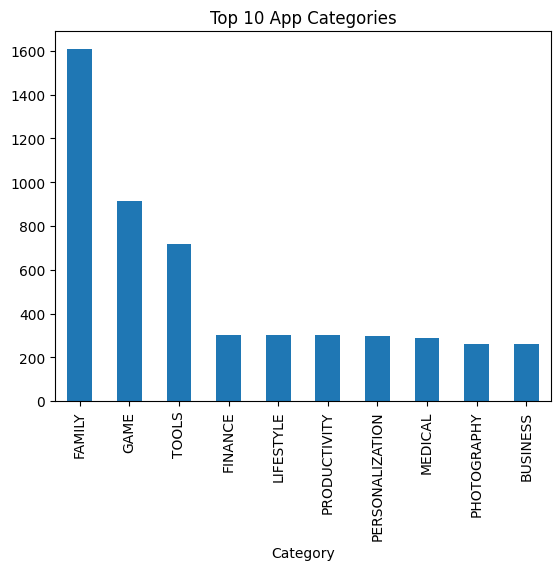

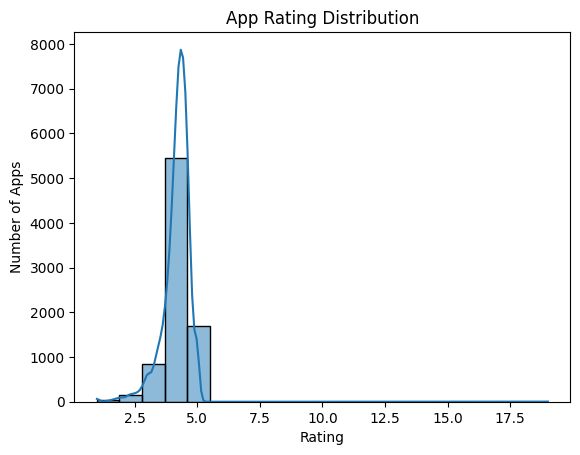

In [ ]:
# Top Categories
top_categories = apps_df['Category'].value_counts().head(10)
top_categories.plot(kind='bar', title='Top 10 App Categories')
plt.show()

# App Rating Distribution
sns.histplot(apps_df['Rating'], bins=20, kde=True)
plt.title('App Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.show()


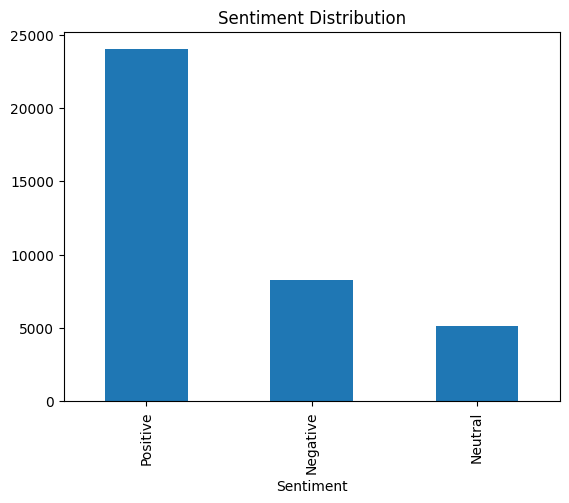

In [ ]:
# Sentiment distribution
reviews_df['Sentiment'].value_counts().plot(kind='bar', title='Sentiment Distribution')
plt.show()


In [ ]:
# Download VADER lexicon if not already
nltk.download('vader_lexicon')

# Initialize sentiment analyzer
sid = SentimentIntensityAnalyzer()

# Function to get compound sentiment score
def get_sentiment(text):
    score = sid.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply to dataset
reviews_df['Predicted_Sentiment'] = reviews_df['Translated_Review'].apply(get_sentiment)

# Compare original vs predicted
print(reviews_df[['Sentiment', 'Predicted_Sentiment']].head())


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


  Sentiment Predicted_Sentiment
0  Positive            Positive
1  Positive            Positive
2  Positive            Positive
3  Positive            Positive
4  Positive            Positive


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Only keep rows with Sentiment
reviews_model_df = reviews_df[reviews_df['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])]
reviews_model_df = reviews_model_df.dropna(subset=['Translated_Review'])
reviews_model_df['Translated_Review'] = reviews_model_df['Translated_Review'].fillna("")

# TF-IDF Vectorizer (LIMITED FEATURES)
vectorizer = TfidfVectorizer(max_features=1000)  # earlier 5000, now 1000
X = vectorizer.fit_transform(reviews_model_df['Translated_Review']).toarray()
y = reviews_model_df['Sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# RandomForest Model (LIMITED TREES)
model = RandomForestClassifier(n_estimators=50)  # earlier 100 trees, now 50
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[1259  104  290]
 [  20  943   86]
 [ 107   96 4581]]
              precision    recall  f1-score   support

    Negative       0.91      0.76      0.83      1653
     Neutral       0.83      0.90      0.86      1049
    Positive       0.92      0.96      0.94      4784

    accuracy                           0.91      7486
   macro avg       0.89      0.87      0.88      7486
weighted avg       0.91      0.91      0.90      7486



In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)


LogisticRegression(max_iter=500)

In [ ]:
import sqlite3

# Create a SQLite database
conn = sqlite3.connect('googleplaystore.db')

# Save cleaned datasets
apps_df.to_sql('apps', conn, if_exists='replace', index=False)
reviews_df.to_sql('reviews', conn, if_exists='replace', index=False)

# Check tables
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

# Close connection
conn.close()


[('apps',), ('reviews',)]


In [ ]:
import sqlite3

# Create a SQLite database
conn = sqlite3.connect('googleplaystore.db')

# Save cleaned datasets
apps_df.to_sql('apps', conn, if_exists='replace', index=False)
reviews_df.to_sql('reviews', conn, if_exists='replace', index=False)

# Check tables
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

# Close connection
conn.close()


[('apps',), ('reviews',)]


In [ ]:
# Export cleaned data
apps_df.to_excel('Cleaned_GooglePlayStore_Apps.xlsx', index=False)
reviews_df.to_excel('Cleaned_GooglePlayStore_Reviews.xlsx', index=False)
